
<h1 id="Decision-Tree-Classifiers">Decision Tree Classifiers</h1>



<h2 id="The-Data">The Data</h2><p>We will work with the "Palmer Penguins" dataset.</p>
<!-- 
<figure>
    <img src="penguins.jpg", width='500', style="display: block; margin: 0 auto">
</figure>  -->



<p>Source: Gorman KB, Williams TD, Fraser WR (2014) "<em>Ecological Sexual Dimorphism and Environmental Variability within a Community of Antarctic Penguins (Genus Pygoscelis).</em>" PLoS ONE 9(3): e90081. doi:10.1371/journal.pone.0090081</p>
<p>Summary:</p>
<ul>
<li><p><code>penguins_size.csv</code>: Simplified data from original penguin data sets. Contains variables:</p>
<ul>
<li><code>species</code>: penguin species (Chinstrap, Adélie, or Gentoo)</li>
<li><code>culmen_length_mm</code>: culmen length (mm)</li>
<li><code>culmen_depth_mm</code>: culmen depth (mm)</li>
<li><code>flipper_length_mm</code>: flipper length (mm)</li>
<li><code>body_mass_g</code>: body mass (g)</li>
<li><code>island</code>: island name (Dream, Torgersen, or Biscoe) in the Palmer Archipelago (Antarctica)</li>
<li><code>sex</code>: penguin sex</li>
</ul>
</li>
</ul>
<p><strong>Goal</strong>: Train a classifier that can help predict a species of a penguin based on physical attributes.</p>



<h2 id="Imports-and-DataFrame-conversion">Imports and DataFrame conversion</h2><ul>
<li>Import the necessary libraries: Pandas, Numpy, Seaborn, and Pyplot.</li>
<li>Read the <code>penguin_size.csv</code> file into a DataFrame called <code>df</code>.</li>
</ul>


In [126]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [127]:
df = pd.read_csv('/Users/jirissman/Documents/coursework/BU/CS767/Homework Assignments/Hw6/penguins_size.csv')


<ul>
<li>How many features does this data set have? What are they?</li>
<li>How many data points does this data set have?</li>
<li>Print the last 6 data points in <code>df</code></li>
</ul>


In [128]:
num_features = len(df.columns)
feature_names = df.columns.tolist()
print(f"The dataset has {num_features} features: {feature_names}")


The dataset has 7 features: ['species', 'island', 'culmen_length_mm', 'culmen_depth_mm', 'flipper_length_mm', 'body_mass_g', 'sex']


In [129]:
num_datapoints = len(df)
print(f"The dataset has {num_datapoints} data points")

The dataset has 344 data points


In [130]:
df.tail(6)

,species,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
338,Gentoo,Biscoe,47.2,13.7,214.0,4925.0,FEMALE
339,Gentoo,Biscoe,NaN,NaN,NaN,NaN,NaN
340,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,FEMALE
341,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,MALE
342,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,FEMALE
343,Gentoo,Biscoe,49.9,16.1,213.0,5400.0,MALE



<h1 id="Initial-Data-Analysis">Initial Data Analysis</h1><h3 id="Finding-Missing-Data.">Finding Missing Data.</h3><ul>
<li>How many features are missing information? Generate a table with the name of the feature and the number of missing features, starting with the feature missing the most data points and going down in decreasing order of missing data points (Hint: can you use the <code>isna()</code> method here?).</li>
<li>What percentage of data points is the top feature entry in your table missing? If this percentage is small enough (roughly less than 10%), drop those data points with missing entries. How many entries are you left with?</li>
</ul>


In [131]:
missing_data = df.isna().sum().sort_values(ascending=False)
missing_data

sex                  10
culmen_length_mm      2
culmen_depth_mm       2
flipper_length_mm     2
body_mass_g           2
species               0
island                0
dtype: int64

In [132]:
print(f"The feature missing the most data points is {missing_data.index[0]} with {missing_data.iloc[0]/num_datapoints*100:.2f}% missing data")
df = df.dropna()
print(f"The dataset with no missing data has {len(df)} data points")

The feature missing the most data points is sex with 2.91% missing data
The dataset with no missing data has 334 data points


In [133]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 334 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            334 non-null    object 
 1   island             334 non-null    object 
 2   culmen_length_mm   334 non-null    float64
 3   culmen_depth_mm    334 non-null    float64
 4   flipper_length_mm  334 non-null    float64
 5   body_mass_g        334 non-null    float64
 6   sex                334 non-null    object 
dtypes: float64(4), object(3)
memory usage: 20.9+ KB


In [134]:
df.head()

,species,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,MALE



<ul>
<li>What values can the <code>island</code> feature take? Print them.</li>
<li>What values can the <code>sex</code> feature take? Print them. If there are any data points where the researchers were unable to determine/record the sex of the penguin, remove them from your data frame.</li>
<li>What values can the label take? Print them.</li>
</ul>


In [135]:
print(f"Unique values for 'island' feature: {df['island'].unique()}")

Unique values for 'island' feature: ['Torgersen' 'Biscoe' 'Dream']


In [136]:
print(f"Unique values for 'sex' feature: {df['sex'].unique()}")
df = df[df['sex'].isin(['MALE', 'FEMALE'])]
print(f"After filtering for determined sex, the dataset has {len(df)} data points")

Unique values for 'sex' feature: ['MALE' 'FEMALE' '.']
After filtering for determined sex, the dataset has 333 data points


In [137]:
print(f"Unique values for the label (species): {df['species'].unique()}")

Unique values for the label (species): ['Adelie' 'Chinstrap' 'Gentoo']



<h2 id="Data-Visualization">Data Visualization</h2><ul>
<li>Draw a scatterplot of Culmen Length vs Culmen Depth. Use the classification label as your hue and <code>palette="Dark2"</code> for a high-contrast plot.<ul>
<li>What can you infer from the scatterplot?</li>
</ul>
</li>
<li>Draw a <code>pairplot</code> once again using the classification label as hue.</li>
<li>Draw a categorical plot of Species vs Culmen Length for the different penguin sexes.<ul>
<li>Which groups appear better separated for each sex?</li>
</ul>
</li>
</ul>


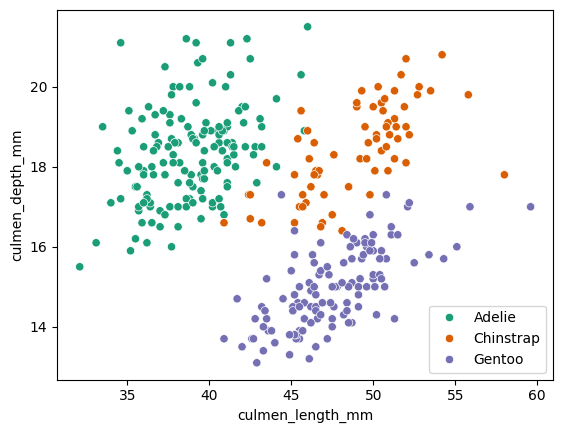

The scatterplot shows that the three species of penguins can be separated based on their culmen length and depth. Gentoo and Chinstrap penguins have similar culmen lengths but different depths, while Adelie penguins have short culmens.


In [138]:
plt.figure()
sns.scatterplot(data=df, x='culmen_length_mm', y='culmen_depth_mm', hue='species', palette='Dark2')
plt.legend(loc='lower right')
plt.show()
print("The scatterplot shows that the three species of penguins can be separated based on their culmen length and depth. "
      "Gentoo and Chinstrap penguins have similar culmen lengths but different depths, while Adelie penguins have short culmens.")

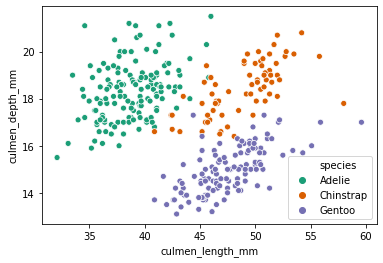

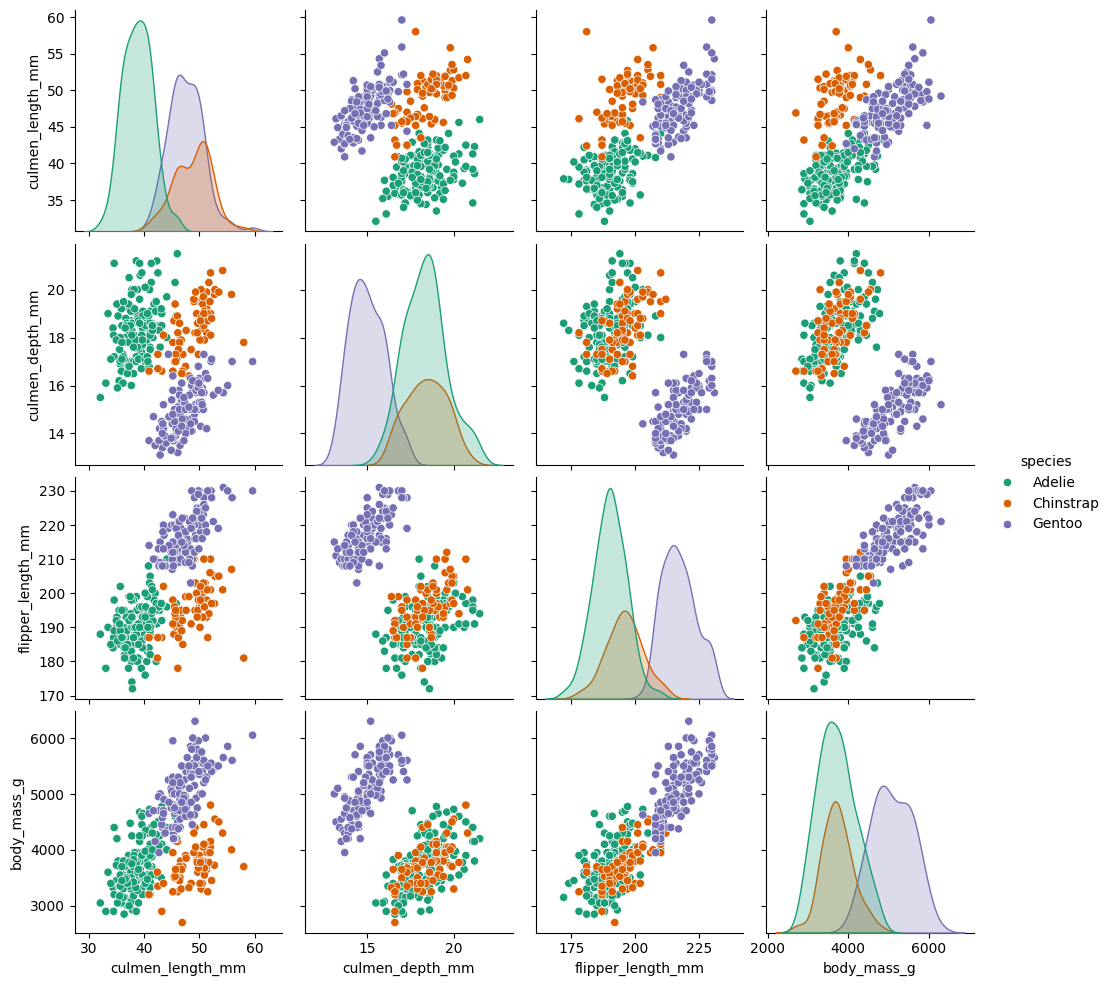

In [139]:
sns.pairplot(df, hue='species', palette='Dark2')
plt.show()

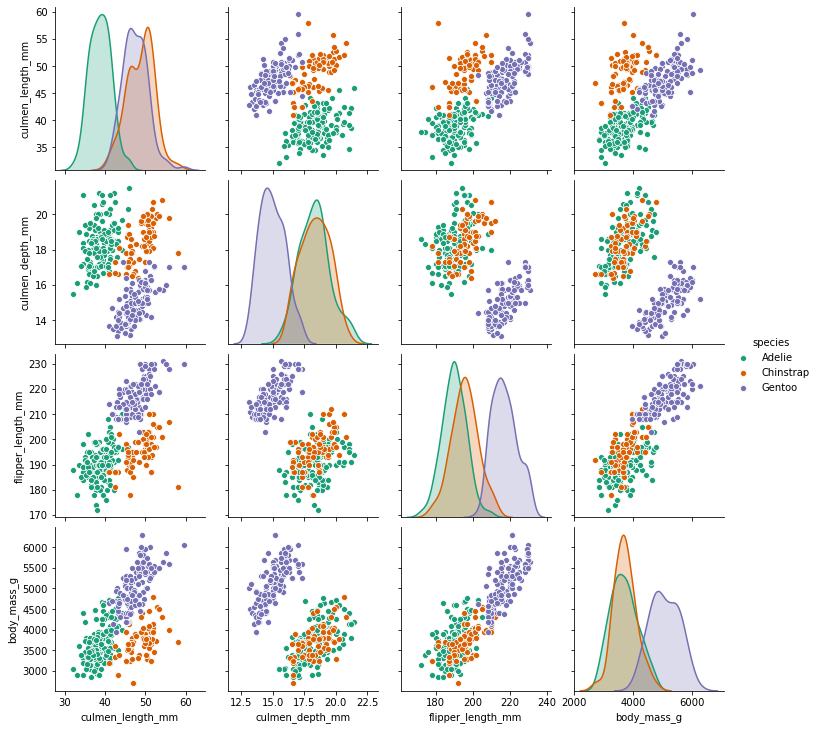

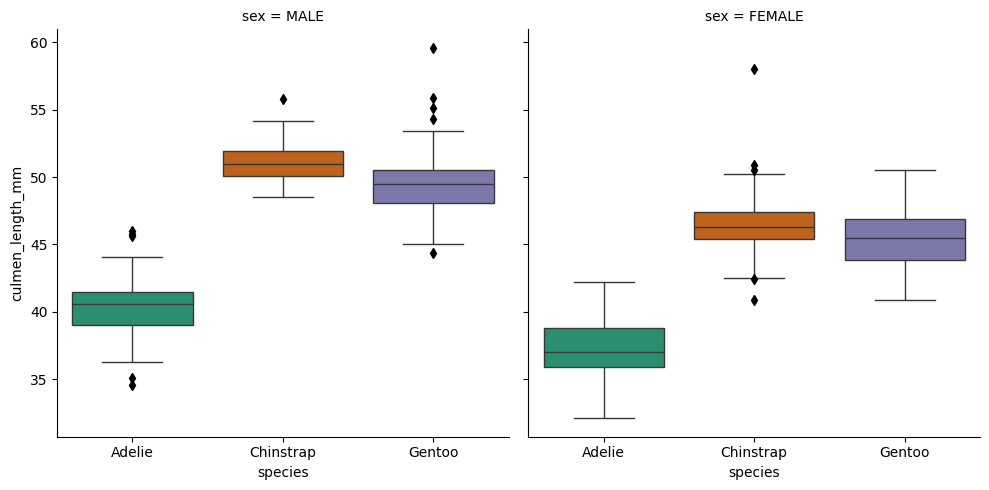

For males, Chinstrap have the longest culmens, but are similar to Gentoo.
For females, Chinstrap and Gentoo have nearly the same culmen lengths.
For both sexes, Adelie penguins have the shortest culmen lengths.


In [140]:
g = sns.catplot(
    data=df, 
    x="species", 
    y="culmen_length_mm", 
    kind="box", 
    col="sex",
    hue="species",
    palette="Dark2",
    height=5,
    flierprops={'marker': 'd', 'markerfacecolor': 'black', 'markeredgecolor': 'black'}
)
g.tight_layout()

plt.show()

print("For males, Chinstrap have the longest culmens, but are similar to Gentoo.")
print("For females, Chinstrap and Gentoo have nearly the same culmen lengths.")
print("For both sexes, Adelie penguins have the shortest culmen lengths.")


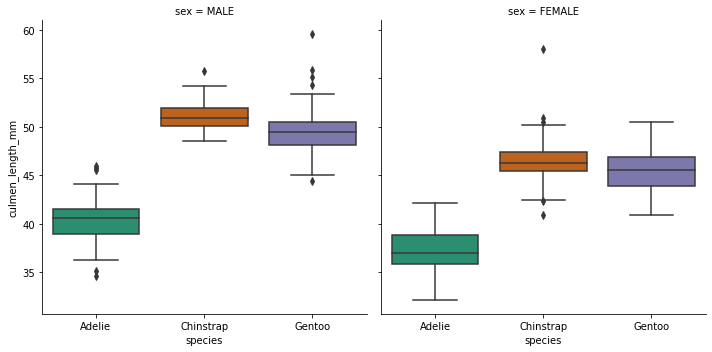


<h2 id="Feature-Engineering">Feature Engineering</h2><ul>
<li>We will now one-hot encode the categorical features.</li>
<li>Research the <code>get_dummies()</code> method on the Scikit-Learn website and use it to one-hot encode <code>species</code>, <code>island</code>, and <code>sex</code>.<ul>
<li>Your data frame post-encoding should look like this.</li>
</ul>
</li>
</ul>


In [141]:
df_encoded = pd.get_dummies(df, columns=['species', 'island', 'sex'])
df_encoded

,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,species_Adelie,species_Chinstrap,species_Gentoo,island_Biscoe,island_Dream,island_Torgersen,sex_FEMALE,sex_MALE
0,39.1,18.7,181.0,3750.0,True,False,False,False,False,True,False,True
1,39.5,17.4,186.0,3800.0,True,False,False,False,False,True,True,False
2,40.3,18.0,195.0,3250.0,True,False,False,False,False,True,True,False
4,36.7,19.3,193.0,3450.0,True,False,False,False,False,True,True,False
5,39.3,20.6,190.0,3650.0,True,False,False,False,False,True,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...
338,47.2,13.7,214.0,4925.0,False,False,True,True,False,False,True,False
340,46.8,14.3,215.0,4850.0,False,False,True,True,False,False,True,False
341,50.4,15.7,222.0,5750.0,False,False,True,True,False,False,False,True
342,45.2,14.8,212.0,5200.0,False,False,True,True,False,False,True,False



<ul>
<li>Once you're done, observe that for every categorical feature that can take $L$ values, you only need $L-1$ columns. Why?</li>
<li>Retain $L-1$ columns and remove the unnecessary column. Your data frame should now look like this.</li>
</ul>


In [142]:
print("For categorical features with L values, we only need L-1 columns because the last value can be determined from the others (if a penguin is not species_Gentoo and not species_Chinstrap, it must be species_Adelie)")
df_features = df.drop(columns=['species'])
df_encoded_features = pd.get_dummies(df_features, columns=['island','sex'], drop_first=True)
df_encoded_features

For categorical features with L values, we only need L-1 columns because the last value can be determined from the others (if a penguin is not species_Gentoo and not species_Chinstrap, it must be species_Adelie)


,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,island_Dream,island_Torgersen,sex_MALE
0,39.1,18.7,181.0,3750.0,False,True,True
1,39.5,17.4,186.0,3800.0,False,True,False
2,40.3,18.0,195.0,3250.0,False,True,False
4,36.7,19.3,193.0,3450.0,False,True,False
5,39.3,20.6,190.0,3650.0,False,True,True
...,...,...,...,...,...,...,...
338,47.2,13.7,214.0,4925.0,False,False,False
340,46.8,14.3,215.0,4850.0,False,False,False
341,50.4,15.7,222.0,5750.0,False,False,True
342,45.2,14.8,212.0,5200.0,False,False,False



<h2 id="Train-%7C-Test-Split">Train | Test Split</h2><ul>
<li>Separate the data frame into features and labels.</li>
<li>Create training and testing sets with a (70:30) split. Use <code>random_state = 101</code>.</li>
<li>Train your <code>DecisionTreeClassifier</code> with default parameters.</li>
<li>While accuracy is the usual metric for classification, we will employ a Confusion Matrix instead.<ul>
<li>Generate the confusion matrix for your fitted model. The information given in Chapter 3, page 108 of the course textbook (which you should have read by now but didn't) might come in handy.</li>
</ul>
</li>
<li>Also, draw the trained decision tree.<ul>
<li>I have used the <code>plot_tree()</code> method along with the <code>filled</code> and <code>feature_names</code> parameters, but you may use <code>export_graphviz</code> instead.</li>
</ul>
</li>
</ul>


In [143]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.tree import plot_tree

In [144]:
X = df_encoded_features
y = df['species']

In [145]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=101)

In [146]:
dt_classifier = DecisionTreeClassifier(random_state=101)
dt_classifier.fit(X_train, y_train)

DecisionTreeClassifier(random_state=101)

<Figure size 640x480 with 0 Axes>

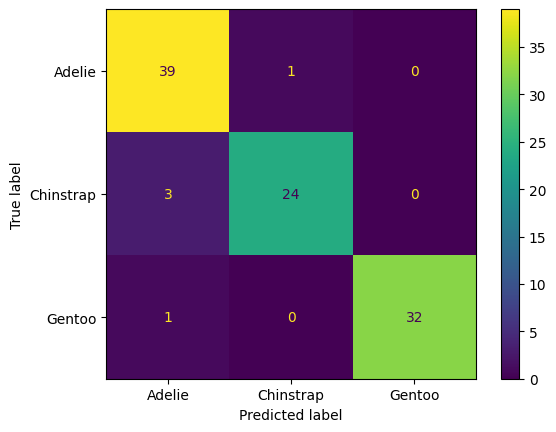

In [147]:
y_pred = dt_classifier.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=dt_classifier.classes_)
plt.figure()
disp.plot()
plt.show()

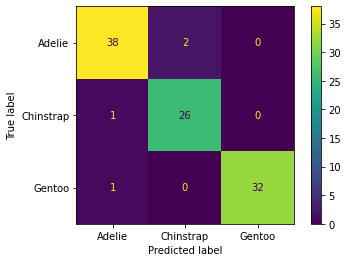

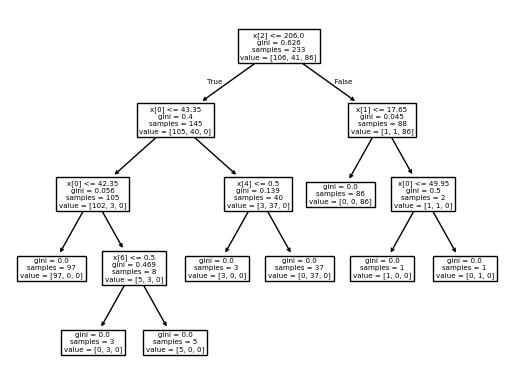

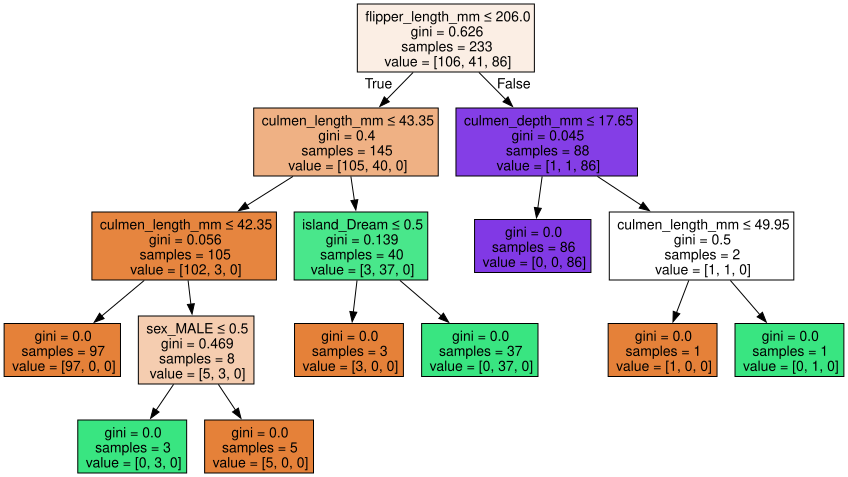

In [148]:
from sklearn.tree import export_graphviz
import graphviz

plt.figure()
plot_tree(dt_classifier)
plt.show()

dot_data = export_graphviz(
    dt_classifier,
    out_file=None,
    feature_names=X.columns,
    filled=True,
    special_characters=True
)

graph = graphviz.Source(dot_data)
graph

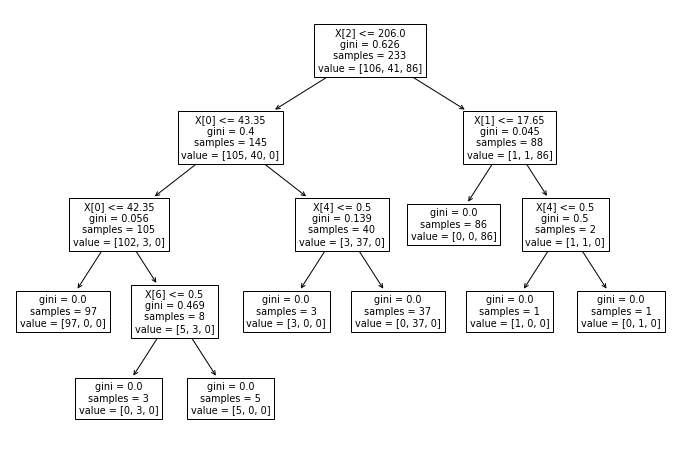
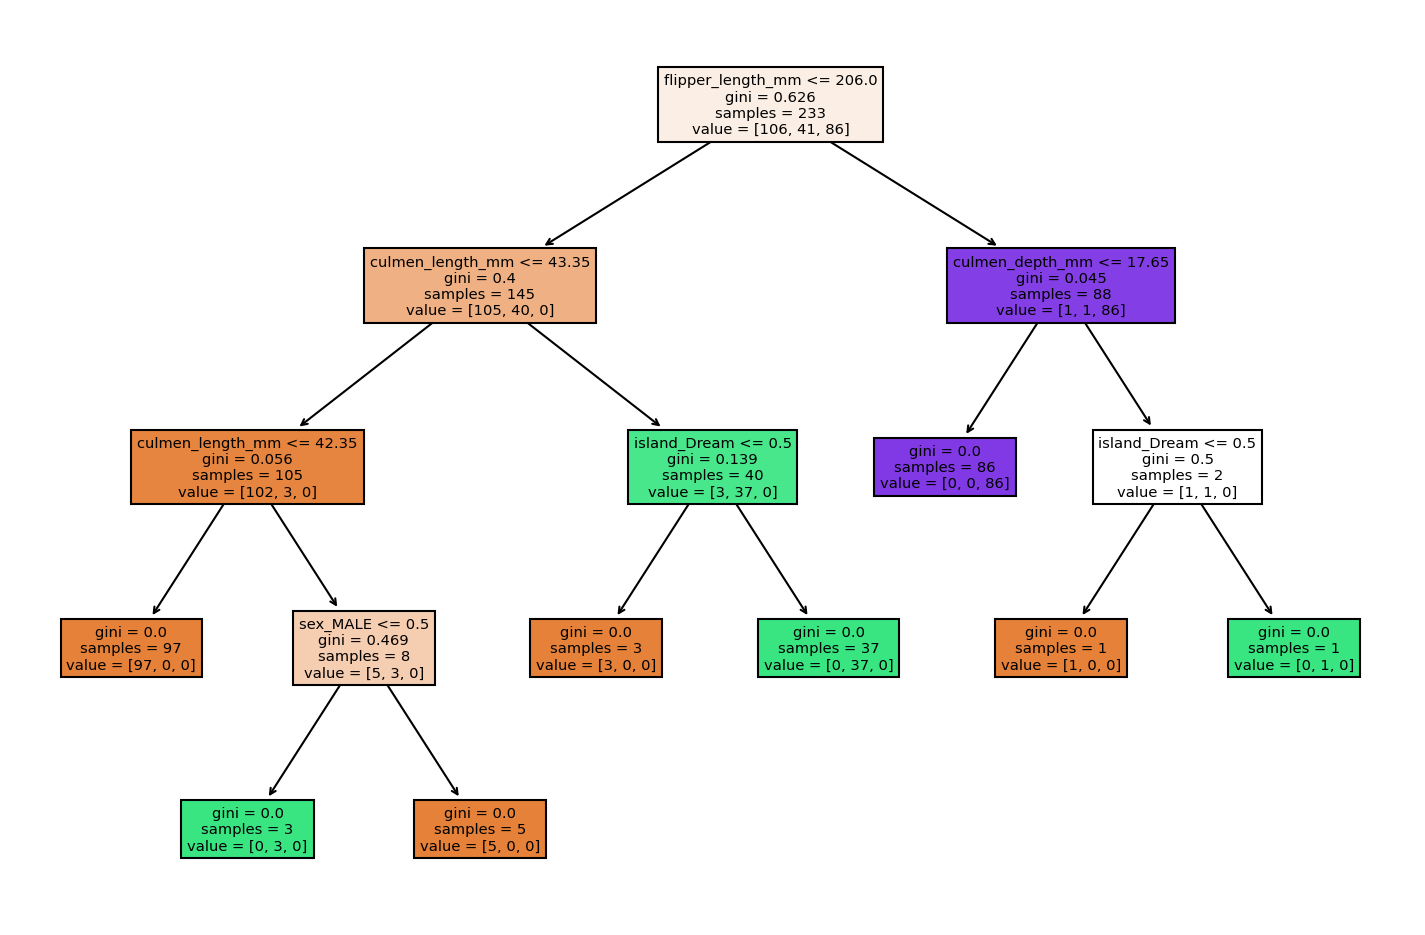


<h2 id="Understanding-Hyperparameters">Understanding Hyperparameters</h2><ul>
<li>Retrain the tree with a maximum depth of 2 and draw the tree.</li>
<li>Retrain the tree with maximum of 3 leaves and draw the tree.</li>
<li>Use Entropy instead of Gini Index and retrain the tree.</li>
</ul>


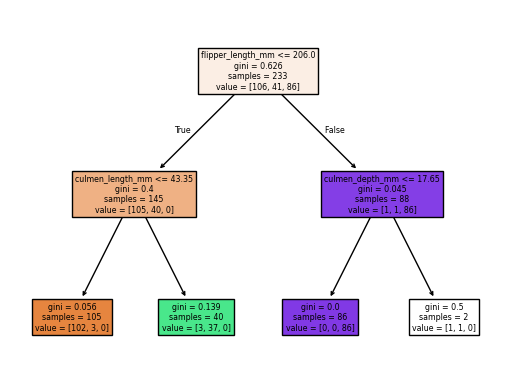

In [149]:
dt_max_depth_2 = DecisionTreeClassifier(max_depth=2, random_state=101)
dt_max_depth_2.fit(X_train, y_train)

plt.figure()
plot_tree(dt_max_depth_2, filled=True, feature_names=X.columns)
plt.show()

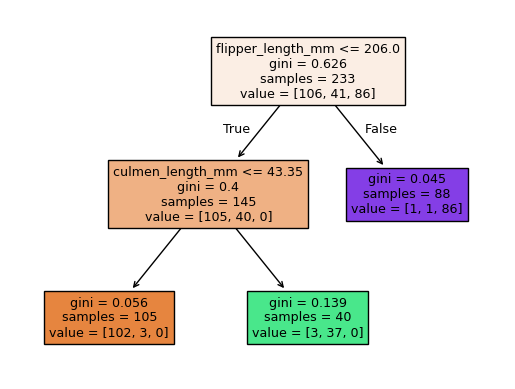

In [150]:
dt_max_leaf_3 = DecisionTreeClassifier(max_leaf_nodes=3, random_state=101)
dt_max_leaf_3.fit(X_train, y_train)

plt.figure()
plot_tree(dt_max_leaf_3, filled=True, feature_names=X.columns)
plt.show()

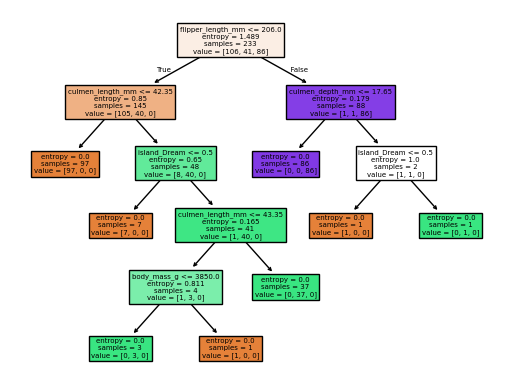

In [151]:
dt_entropy = DecisionTreeClassifier(criterion='entropy', random_state=101)
dt_entropy.fit(X_train, y_train)

plt.figure()
plot_tree(dt_entropy, filled=True, feature_names=X.columns)
plt.show()


<hr/>
